# 🫀 Heart Disease Prediction + Explainable AI (SHAP)

Analyse complète : EDA → preprocessing → modélisation → comparaison → SHAP.

> ⚠️ Projet académique de démonstration, pas un outil de diagnostic médical.

## 1. Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, ConfusionMatrixDisplay, RocCurveDisplay
)

sns.set_style("whitegrid")
%matplotlib inline

## 2. Chargement des données

In [2]:
df = pd.read_csv("../data/heart.csv")
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [3]:
print("Shape:", df.shape)
print("\nValeurs manquantes:\n", df.isna().sum())
print("\nDistribution de la cible:\n", df['target'].value_counts())

Shape: (303, 14)

Valeurs manquantes:
 age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

Distribution de la cible:
 target
1    165
0    138
Name: count, dtype: int64


## 3. Analyse exploratoire (EDA)

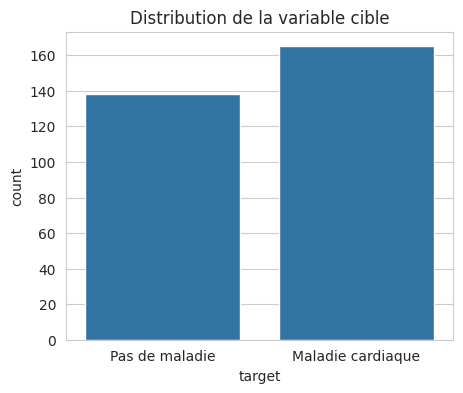

In [4]:
plt.figure(figsize=(5,4))
sns.countplot(x=df["target"])
plt.xticks([0,1], ["Pas de maladie", "Maladie cardiaque"])
plt.title("Distribution de la variable cible")
plt.show()

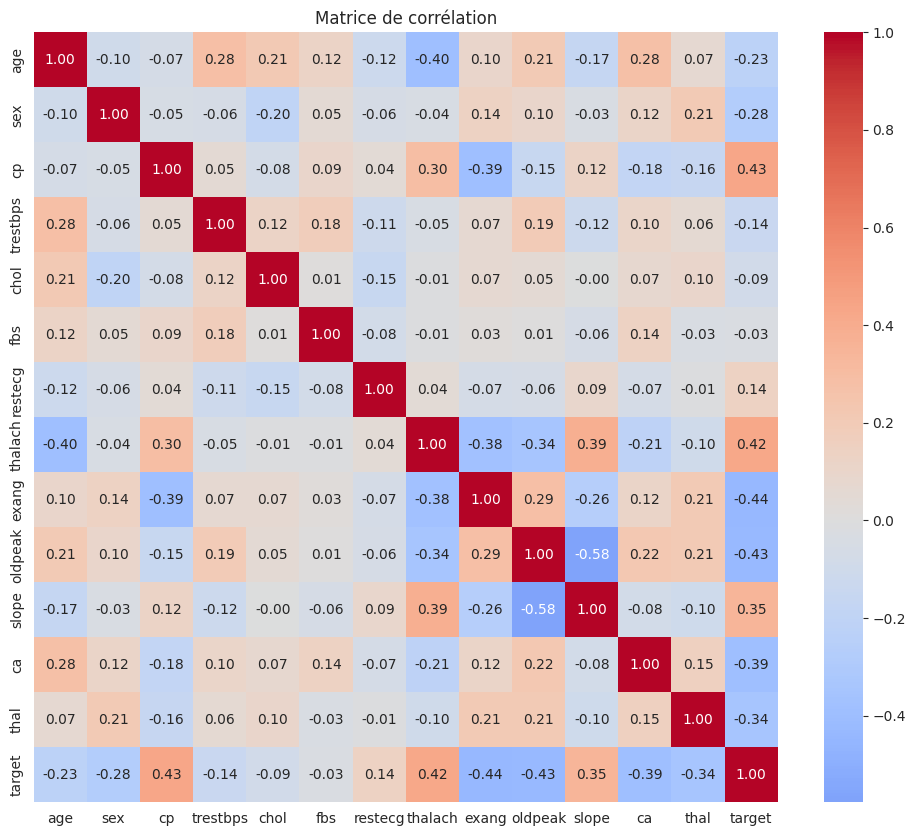

In [5]:
plt.figure(figsize=(12,10))
sns.heatmap(df.corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Matrice de corrélation")
plt.show()

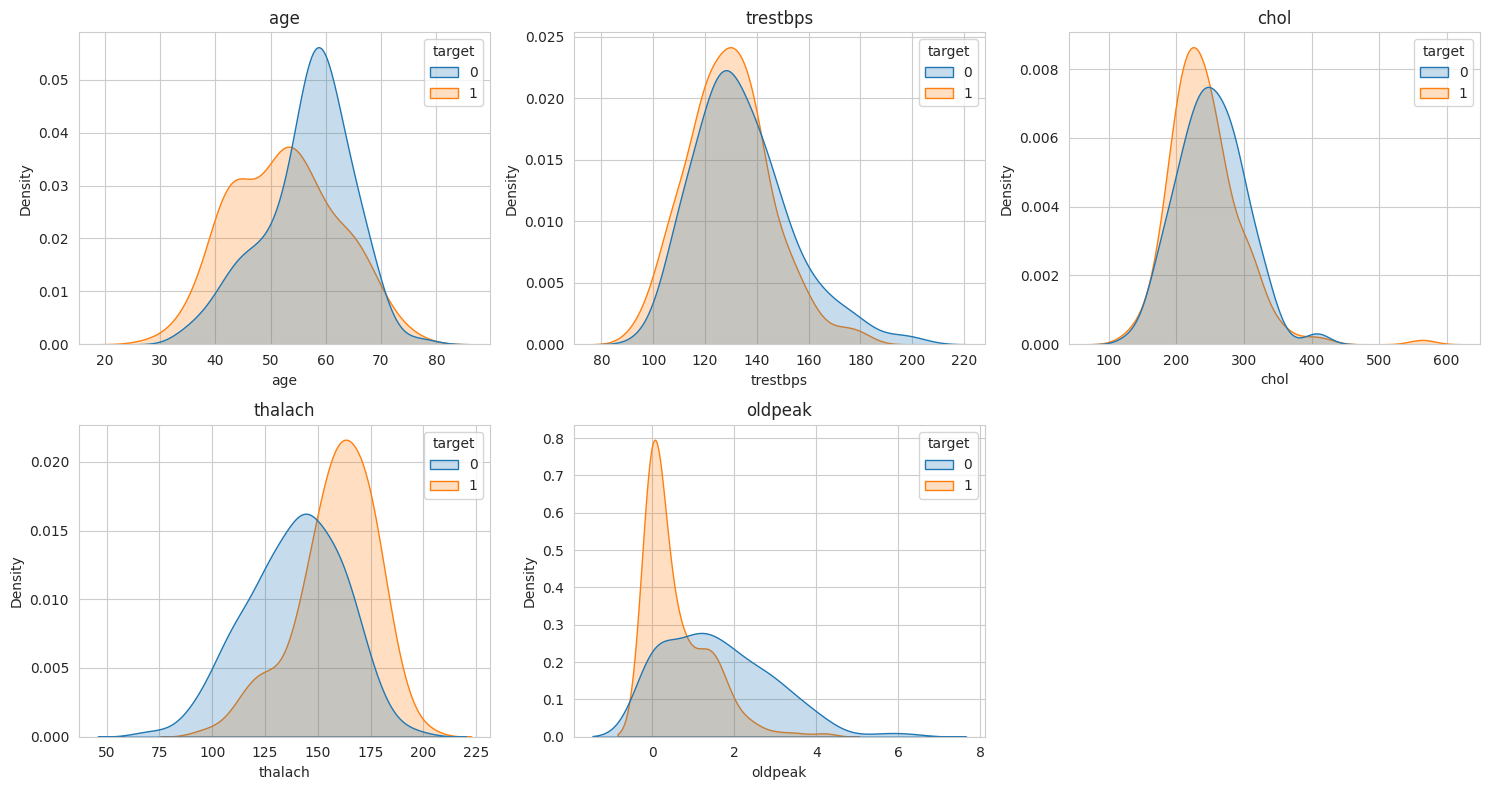

In [6]:
fig, axes = plt.subplots(2, 3, figsize=(15,8))
num_cols = ["age","trestbps","chol","thalach","oldpeak"]
for ax, col in zip(axes.flat, num_cols):
    sns.kdeplot(data=df, x=col, hue="target", ax=ax, fill=True, common_norm=False)
    ax.set_title(col)
axes.flat[-1].axis("off")
plt.tight_layout()
plt.show()

## 4. Preprocessing

Encodage one-hot des variables catégorielles, split train/test stratifié, standardisation des variables numériques.

In [7]:
CATEGORICAL_COLS = ["cp", "restecg", "slope", "thal"]
NUMERIC_COLS = ["age", "trestbps", "chol", "thalach", "oldpeak", "ca"]

X = df.drop(columns=["target"])
y = df["target"]

X = pd.get_dummies(X, columns=CATEGORICAL_COLS).astype("float64")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train[NUMERIC_COLS] = scaler.fit_transform(X_train[NUMERIC_COLS])
X_test[NUMERIC_COLS] = scaler.transform(X_test[NUMERIC_COLS])

print("Train:", X_train.shape, " Test:", X_test.shape)

Train: (242, 23)  Test: (61, 23)


## 5. Modélisation : comparaison de 3 modèles

In [8]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=300, random_state=42),
    "XGBoost": XGBClassifier(n_estimators=300, max_depth=4, learning_rate=0.05,
                              eval_metric="logloss", random_state=42),
}

results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]
    results[name] = {
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred),
        "recall": recall_score(y_test, y_pred),
        "f1": f1_score(y_test, y_pred),
        "roc_auc": roc_auc_score(y_test, y_proba),
    }

results_df = pd.DataFrame(results).T.round(3)
results_df

,accuracy,precision,recall,f1,roc_auc
Logistic Regression,0.803,0.784,0.879,0.829,0.885
Random Forest,0.787,0.763,0.879,0.817,0.899
XGBoost,0.770,0.757,0.848,0.800,0.861


### Matrices de confusion

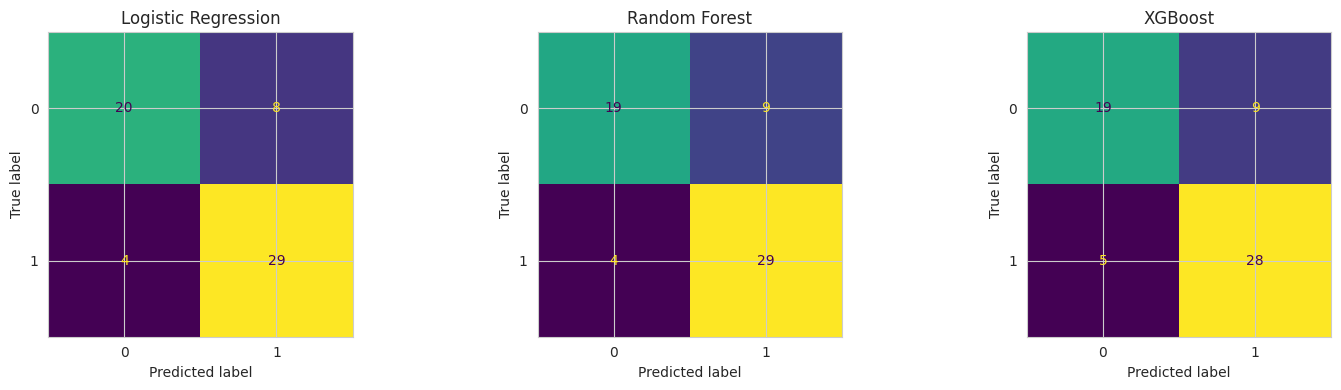

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(15,4))
for ax, (name, model) in zip(axes, models.items()):
    ConfusionMatrixDisplay.from_estimator(model, X_test, y_test, ax=ax, colorbar=False)
    ax.set_title(name)
plt.tight_layout()
plt.show()

### Courbes ROC comparées

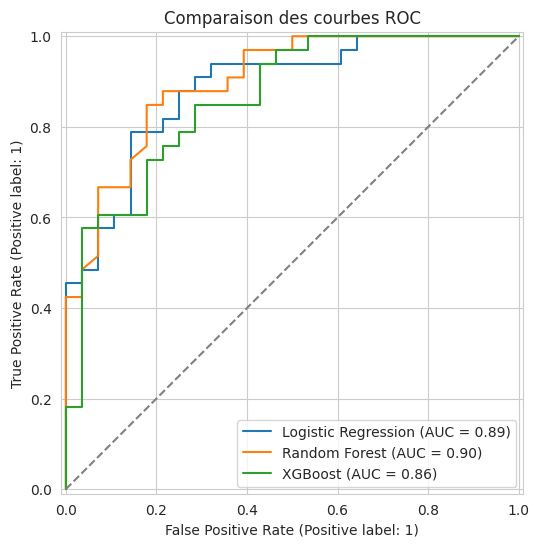

In [10]:
fig, ax = plt.subplots(figsize=(7,6))
for name, model in models.items():
    RocCurveDisplay.from_estimator(model, X_test, y_test, ax=ax, name=name)
ax.plot([0,1],[0,1], linestyle="--", color="gray")
ax.set_title("Comparaison des courbes ROC")
plt.show()

## 6. Sélection du meilleur modèle

In [11]:
best_name = results_df["f1"].idxmax()
best_model = models[best_name]
print(f"Meilleur modèle (F1-score) : {best_name}")
results_df

Meilleur modèle (F1-score) : Logistic Regression


,accuracy,precision,recall,f1,roc_auc
Logistic Regression,0.803,0.784,0.879,0.829,0.885
Random Forest,0.787,0.763,0.879,0.817,0.899
XGBoost,0.770,0.757,0.848,0.800,0.861


## 7. Explicabilité avec SHAP 🧠

On explique maintenant le meilleur modèle : quelles variables comptent le plus, et pourquoi une prédiction individuelle donnée est faite.

In [12]:
if type(best_model).__name__ in ("RandomForestClassifier", "XGBClassifier"):
    explainer = shap.TreeExplainer(best_model)
else:
    explainer = shap.LinearExplainer(best_model, X_train)

shap_values = explainer(X_test)
if len(shap_values.shape) == 3:
    shap_values_plot = shap_values[:, :, 1]
else:
    shap_values_plot = shap_values

Background dataset has 242 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=242 when initializing the masker.


### Summary plot — impact global de chaque variable

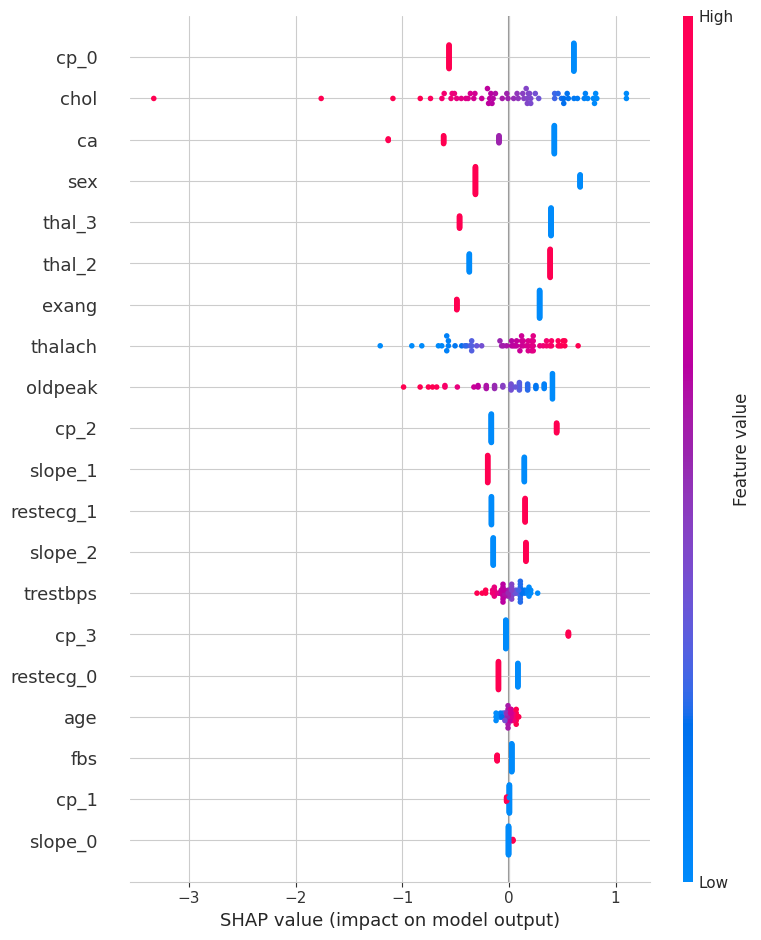

In [13]:
shap.summary_plot(shap_values_plot, X_test)

### Bar plot — importance moyenne absolue

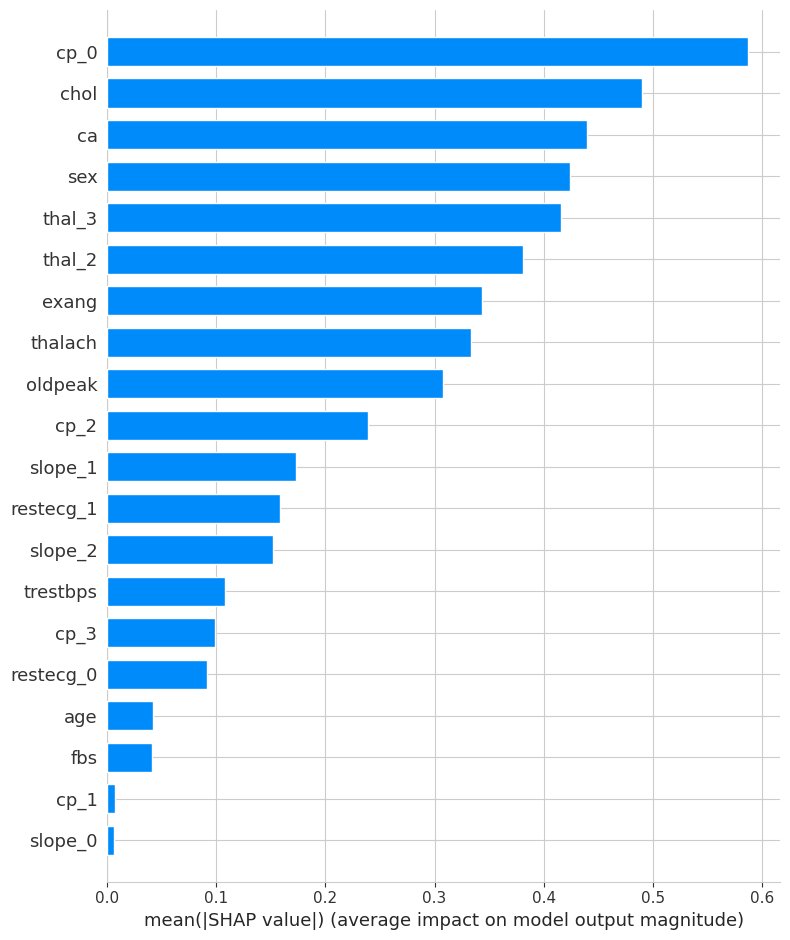

In [14]:
shap.summary_plot(shap_values_plot, X_test, plot_type="bar")

### Waterfall plot — explication d'une prédiction individuelle

Exemple : le premier patient du jeu de test.

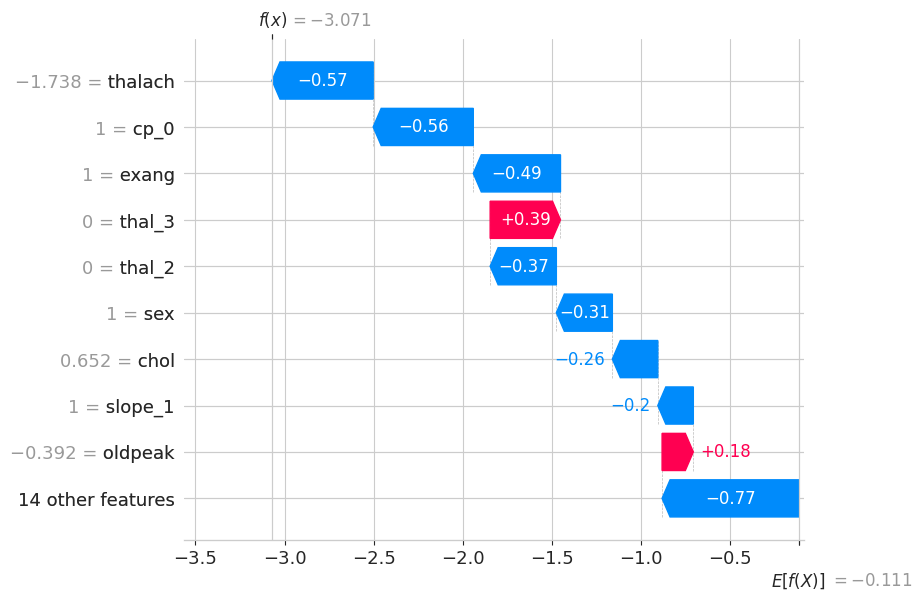

In [15]:
shap.plots.waterfall(shap_values_plot[0])

## 8. Sauvegarde du modèle final

In [16]:
import joblib

joblib.dump(
    {"model": best_model, "scaler": scaler, "columns": X_train.columns.tolist(), "model_name": best_name},
    "../models/best_model.joblib"
)
print("Modèle sauvegardé.")

Modèle sauvegardé.


## Conclusion

- Les 3 modèles obtiennent des performances comparables (F1 ≈ 0.80–0.83, ROC-AUC ≈ 0.86–0.90)
- **SHAP** permet de dépasser la simple prédiction binaire : on comprend *pourquoi* un patient est classé à risque
- Les facteurs les plus influents (type de douleur thoracique, cholestérol, vaisseaux colorés, sexe) sont cohérents avec la littérature médicale

⚠️ Rappel : projet académique, pas un outil de diagnostic clinique.